## 1) Imports + cấu hình hiển thị

In [44]:
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import TransformedTargetRegressor



## 2) Tham số / đường dẫn

In [45]:
# chỉnh nếu cần
INPUT_CSV = "moso_clean.csv"
OUTDIR = Path("model_out")
model_path = OUTDIR / "rf_price_pipeline.joblib"
TEST_SIZE = 0.2
RANDOM_STATE = 42
LOG_TARGET = True            # True: dùng log1p cho mục tiêu
inp = Path(INPUT_CSV)
if not inp.exists():
    raise SystemExit(f"Không tìm thấy file: {inp}")
df = pd.read_csv(inp)
print("📂 Loaded:", inp.name, "| rows:", len(df), "| cols:", len(df.columns))
display(df.head(5))

OUTDIR.mkdir(parents=True, exist_ok=True)
print("Input:", INPUT_CSV, "| Outdir:", OUTDIR)


📂 Loaded: moso_clean.csv | rows: 2230 | cols: 24


,URL,Giá,Diện tích sử dụng,Diện tích đất,Phòng ngủ,Phòng tắm,Giấy tờ pháp lý,Ngày đăng,Địa chỉ,Giá (VND),...,Diện tích sử dụng_mm,Diện tích đất_std,Diện tích đất_mm,Số ngày từ đăng_std,Số ngày từ đăng_mm,Tỉnh/TP,Quận/Huyện/TP,Phường/Xã/TT,Đường/Số nhà,Địa chỉ (chuẩn)
0,https://moso.vn/ban-690388d2d638883988715f20,23.5 Tỷ,256.5100,162.0000,4.0000,4.0000,certificate,30/10/2025,"46 Đường Số 20, Hiệp Bình Chánh, Thủ Đức, Hồ C...","23,500,000,000.0000",...,0.6201,2.9400,0.9113,-1.4581,0.0000,Hồ Chí Minh,TP Thủ Đức,Phường Hiệp Bình Chánh,"46 Đường Số 20, Hồ Chí Minh","46 Đường Số 20, Hiệp Bình Chánh, Thủ Đức, Hồ C..."
1,https://moso.vn/ban-690375a5d638883988712dd5,4.8 Tỷ,117.0500,79.8000,NaN,NaN,certificate,30/10/2025,"Đường Lê Đức Thọ, 16, Gò Vấp, Hồ Chí Minh","4,800,000,000.0000",...,0.2735,0.4309,0.4348,-1.4581,0.0000,Hồ Chí Minh,Quận Gò Vấp,Phường 16,"Đường Lê Đức Thọ, Hồ Chí Minh","Đường Lê Đức Thọ, 16, Gò Vấp, Hồ Chí Minh"
2,https://moso.vn/ban-69034b76d63888398870c2cf,4.8 Tỷ,60.6000,77.1000,6.0000,6.0000,certificate,30/10/2025,"2/23A Đường số 13, Linh Xuân, Thủ Đức, Hồ Chí ...","4,800,000,000.0000",...,0.1332,0.3485,0.4191,-1.4581,0.0000,Hồ Chí Minh,TP Thủ Đức,Phường Linh Xuân,"2/23A Đường số 13, Hồ Chí Minh","2/23A Đường số 13, Linh Xuân, Thủ Đức, Hồ Chí ..."
3,https://moso.vn/ban-69034961d63888398870bc4c,21.5 Tỷ,66.2000,66.2000,2.0000,1.0000,certificate,30/10/2025,"801/43 Đường Xô Viết Nghệ Tĩnh, 25, Bình Thạnh...","21,500,000,000.0000",...,0.1471,0.0157,0.3559,-1.4581,0.0000,Hồ Chí Minh,Quận Bình Thạnh,Phường 25,"801/43 Đường Xô Viết Nghệ Tĩnh, Hồ Chí Minh","801/43 Đường Xô Viết Nghệ Tĩnh, 25, Bình Thạnh..."
4,https://moso.vn/ban-6903475dd63888398870b555,1.8 Tỷ,26.0000,9.3000,1.0000,1.0000,certificate,30/10/2025,"40/13/27 Đường Số 2, 3, Gò Vấp, Hồ Chí Minh","1,800,000,000.0000",...,0.0472,-1.7211,0.0261,-1.4581,0.0000,Hồ Chí Minh,Quận Gò Vấp,Phường 3,"40/13/27 Đường Số 2, Hồ Chí Minh","40/13/27 Đường Số 2, 3, Gò Vấp, Hồ Chí Minh"


Input: moso_clean.csv | Outdir: model_out


## 3) Hàm tiện ích + vẽ

In [46]:
def fmt_vnd_to_bil(x):
    return x / 1e9

def describe_metrics(y_true_vnd, y_pred_vnd):
    mae = mean_absolute_error(y_true_vnd, y_pred_vnd)
    rmse = np.sqrt(mean_squared_error(y_true_vnd, y_pred_vnd))
    r2 = r2_score(y_true_vnd, y_pred_vnd)
    return {
        "MAE_VND": mae,
        "RMSE_VND": rmse,
        "R2": r2,
        "MAE_bil": fmt_vnd_to_bil(mae),
        "RMSE_bil": fmt_vnd_to_bil(rmse),
    }

def plot_parity(ax, y_true_vnd, y_pred_vnd, title="Thật vs Dự đoán (tỷ VND)"):
    yt = fmt_vnd_to_bil(np.asarray(y_true_vnd))
    yp = fmt_vnd_to_bil(np.asarray(y_pred_vnd))
    ax.scatter(yt, yp, s=14, alpha=0.6)
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xlabel("Giá thật (tỷ VND)")
    ax.set_ylabel("Giá dự đoán (tỷ VND)")
    ax.set_title(title)
    ax.grid(alpha=0.25)

def plot_residual_hist(ax, y_true_vnd, y_pred_vnd, bins=50, title="Phân bố sai số (tỷ VND)"):
    resid_bil = fmt_vnd_to_bil(np.asarray(y_pred_vnd) - np.asarray(y_true_vnd))
    ax.hist(resid_bil, bins=bins)
    ax.set_xlabel("Sai số = Dự đoán - Thật (tỷ VND)")
    ax.set_ylabel("Số mẫu")
    ax.set_title(title)
    ax.grid(alpha=0.25)

def plot_residual_scatter(ax, y_pred_vnd, y_true_vnd, title="Sai số theo Giá dự đoán"):
    resid_bil = fmt_vnd_to_bil(np.asarray(y_pred_vnd) - np.asarray(y_true_vnd))
    ypred_bil = fmt_vnd_to_bil(np.asarray(y_pred_vnd))
    ax.scatter(ypred_bil, resid_bil, s=12, alpha=0.6)
    ax.axhline(0, color="k", lw=1, ls="--")
    ax.set_xlabel("Giá dự đoán (tỷ VND)")
    ax.set_ylabel("Sai số (tỷ VND)")
    ax.set_title(title)
    ax.grid(alpha=0.25)

def plot_error_by_district(ax, df_test, y_true_vnd, y_pred_vnd, top=15, agg="mae"):
    tmp = df_test.copy()
    tmp["__y_true"] = y_true_vnd
    tmp["__y_pred"] = y_pred_vnd
    tmp["__abs_err_bil"] = np.abs(tmp["__y_pred"] - tmp["__y_true"]) / 1e9

    vc = tmp["Quận/Huyện/TP"].astype(str).value_counts().head(top)
    keep = vc.index
    sub = tmp[tmp["Quận/Huyện/TP"].astype(str).isin(keep)].copy()

    if agg == "mae":
        s = sub.groupby("Quận/Huyện/TP")["__abs_err_bil"].mean().sort_values(ascending=False)
        ax.set_title(f"MAE theo quận (tỷ VND) - Top {top}")
        ax.set_xlabel("MAE (tỷ VND)")
    else:
        s = sub.groupby("Quận/Huyện/TP").apply(
            lambda g: np.sqrt(np.mean(((g["__y_pred"] - g["__y_true"]) / 1e9) ** 2))
        ).sort_values(ascending=False)
        ax.set_title(f"RMSE theo quận (tỷ VND) - Top {top}")
        ax.set_xlabel("RMSE (tỷ VND)")

    ax.barh(s.index, s.values)
    ax.invert_yaxis()
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)

from sklearn.model_selection import learning_curve, validation_curve

def plot_learning_curve(model, X, y, ax=None, scoring="neg_mean_absolute_error", cv=3, random_state=42):
    """
    Vẽ đường cong học (Learning Curve) thể hiện MAE khi tăng số mẫu train.
    """
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=cv, scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1, random_state=random_state
    )
    train_mae = -train_scores.mean(axis=1)
    val_mae = -val_scores.mean(axis=1)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7.5, 5.5))
    ax.plot(train_sizes, train_mae / 1e9, "o-", label="Train MAE (tỷ VND)")
    ax.plot(train_sizes, val_mae / 1e9, "o-", label="CV MAE (tỷ VND)")
    ax.set_xlabel("Số mẫu huấn luyện")
    ax.set_ylabel("Sai số MAE (tỷ VND)")
    ax.set_title("Learning Curve - Random Forest")
    ax.legend()
    ax.grid(alpha=0.3)
    return ax


def plot_validation_curve(model, X, y, ax=None, param_name="regressor__steps__1__rf__max_depth",
                          param_range=None, scoring="neg_mean_absolute_error", cv=3):
    """
    Vẽ đường cong kiểm định (Validation Curve) theo tham số của mô hình, ví dụ max_depth.
    """
    if param_range is None:
        param_range = [4, 6, 8, 10, 12, 14, 16, 20]

    train_scores, val_scores = validation_curve(
        model, X, y,
        param_name=param_name,
        param_range=param_range,
        cv=cv, scoring=scoring, n_jobs=-1
    )

    train_mae = -train_scores.mean(axis=1)
    val_mae = -val_scores.mean(axis=1)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7.5, 5.5))
    ax.plot(param_range, train_mae / 1e9, "o-", label="Train MAE (tỷ VND)")
    ax.plot(param_range, val_mae / 1e9, "o-", label="CV MAE (tỷ VND)")
    ax.set_xlabel(param_name)
    ax.set_ylabel("Sai số MAE (tỷ VND)")
    ax.set_title("Validation Curve - Random Forest")
    ax.legend()
    ax.grid(alpha=0.3)
    return ax


## 4) Đọc dữ liệu & xem nhanh

In [47]:
df = pd.read_csv(INPUT_CSV)
print("📥 Loaded:", df.shape)
df.head(5)


📥 Loaded: (2230, 24)


,URL,Giá,Diện tích sử dụng,Diện tích đất,Phòng ngủ,Phòng tắm,Giấy tờ pháp lý,Ngày đăng,Địa chỉ,Giá (VND),...,Diện tích sử dụng_mm,Diện tích đất_std,Diện tích đất_mm,Số ngày từ đăng_std,Số ngày từ đăng_mm,Tỉnh/TP,Quận/Huyện/TP,Phường/Xã/TT,Đường/Số nhà,Địa chỉ (chuẩn)
0,https://moso.vn/ban-690388d2d638883988715f20,23.5 Tỷ,256.5100,162.0000,4.0000,4.0000,certificate,30/10/2025,"46 Đường Số 20, Hiệp Bình Chánh, Thủ Đức, Hồ C...","23,500,000,000.0000",...,0.6201,2.9400,0.9113,-1.4581,0.0000,Hồ Chí Minh,TP Thủ Đức,Phường Hiệp Bình Chánh,"46 Đường Số 20, Hồ Chí Minh","46 Đường Số 20, Hiệp Bình Chánh, Thủ Đức, Hồ C..."
1,https://moso.vn/ban-690375a5d638883988712dd5,4.8 Tỷ,117.0500,79.8000,NaN,NaN,certificate,30/10/2025,"Đường Lê Đức Thọ, 16, Gò Vấp, Hồ Chí Minh","4,800,000,000.0000",...,0.2735,0.4309,0.4348,-1.4581,0.0000,Hồ Chí Minh,Quận Gò Vấp,Phường 16,"Đường Lê Đức Thọ, Hồ Chí Minh","Đường Lê Đức Thọ, 16, Gò Vấp, Hồ Chí Minh"
2,https://moso.vn/ban-69034b76d63888398870c2cf,4.8 Tỷ,60.6000,77.1000,6.0000,6.0000,certificate,30/10/2025,"2/23A Đường số 13, Linh Xuân, Thủ Đức, Hồ Chí ...","4,800,000,000.0000",...,0.1332,0.3485,0.4191,-1.4581,0.0000,Hồ Chí Minh,TP Thủ Đức,Phường Linh Xuân,"2/23A Đường số 13, Hồ Chí Minh","2/23A Đường số 13, Linh Xuân, Thủ Đức, Hồ Chí ..."
3,https://moso.vn/ban-69034961d63888398870bc4c,21.5 Tỷ,66.2000,66.2000,2.0000,1.0000,certificate,30/10/2025,"801/43 Đường Xô Viết Nghệ Tĩnh, 25, Bình Thạnh...","21,500,000,000.0000",...,0.1471,0.0157,0.3559,-1.4581,0.0000,Hồ Chí Minh,Quận Bình Thạnh,Phường 25,"801/43 Đường Xô Viết Nghệ Tĩnh, Hồ Chí Minh","801/43 Đường Xô Viết Nghệ Tĩnh, 25, Bình Thạnh..."
4,https://moso.vn/ban-6903475dd63888398870b555,1.8 Tỷ,26.0000,9.3000,1.0000,1.0000,certificate,30/10/2025,"40/13/27 Đường Số 2, 3, Gò Vấp, Hồ Chí Minh","1,800,000,000.0000",...,0.0472,-1.7211,0.0261,-1.4581,0.0000,Hồ Chí Minh,Quận Gò Vấp,Phường 3,"40/13/27 Đường Số 2, Hồ Chí Minh","40/13/27 Đường Số 2, 3, Gò Vấp, Hồ Chí Minh"


## 5) Chọn feature + tạo “Tỷ lệ sử dụng”

In [48]:
feat_num = ["Diện tích sử dụng", "Diện tích đất", "Số ngày từ đăng"]
if "Diện tích sử dụng" in df.columns and "Diện tích đất" in df.columns:
    ratio = (pd.to_numeric(df["Diện tích sử dụng"], errors="coerce") /
             pd.to_numeric(df["Diện tích đất"], errors="coerce"))
    df["Tỷ lệ sử dụng"] = ratio.replace([np.inf, -np.inf], np.nan)
    feat_num.append("Tỷ lệ sử dụng")

feat_cat = ["Quận/Huyện/TP"]
target_col = "Giá (VND)"

print("Numeric:", feat_num)
print("Categorical:", feat_cat)
df[feat_num + feat_cat + [target_col]].head(5)


Numeric: ['Diện tích sử dụng', 'Diện tích đất', 'Số ngày từ đăng', 'Tỷ lệ sử dụng']
Categorical: ['Quận/Huyện/TP']


,Diện tích sử dụng,Diện tích đất,Số ngày từ đăng,Tỷ lệ sử dụng,Quận/Huyện/TP,Giá (VND)
0,256.5100,162.0000,1,1.5834,TP Thủ Đức,"23,500,000,000.0000"
1,117.0500,79.8000,1,1.4668,Quận Gò Vấp,"4,800,000,000.0000"
2,60.6000,77.1000,1,0.7860,TP Thủ Đức,"4,800,000,000.0000"
3,66.2000,66.2000,1,1.0000,Quận Bình Thạnh,"21,500,000,000.0000"
4,26.0000,9.3000,1,2.7957,Quận Gò Vấp,"1,800,000,000.0000"


## 6) Tạo X, y & tách train/test

In [49]:
for c in feat_num:
    assert c in df.columns, f"Thiếu cột số: {c}"
for c in feat_cat:
    assert c in df.columns, f"Thiếu cột phân loại: {c}"
assert target_col in df.columns, f"Thiếu cột mục tiêu: {target_col}"

X = df[feat_num + feat_cat].copy()
y = pd.to_numeric(df[target_col], errors="coerce")

mask = np.isfinite(y)
X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
X_train.head(5)


Train: (1784, 5) | Test: (446, 5)


,Diện tích sử dụng,Diện tích đất,Số ngày từ đăng,Tỷ lệ sử dụng,Quận/Huyện/TP
1255,54.0000,27.0000,68,2.0000,Quận 4
1374,200.5000,80.0000,71,2.5063,Quận Bình Tân
2016,117.0500,50.0000,119,2.3410,Quận Tân Bình
1134,74.6600,60.4300,55,1.2355,Quận 4
1137,23.3802,24.3000,55,0.9621,Quận Bình Thạnh


## 7) Preprocessor (impute + scale + one-hot)

In [50]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), feat_num),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), feat_cat),
    ],
    remainder="drop"
)
print("✅ Preprocessor ready.")


✅ Preprocessor ready.


## 8) Mô hình + Pipeline

In [51]:


# Khởi tạo mô hình Random Forest
LOG_TARGET = True
print("LOG_TARGET =", LOG_TARGET)
rf = RandomForestRegressor(
    n_estimators=500,  # số cây (thường 100–500 là ổn)
    max_depth=10,  # giới hạn độ sâu (tránh overfit)
    min_samples_split=5,  # yêu cầu ít nhất 5 mẫu để tách node
    min_samples_leaf=5,  # ít nhất 3 mẫu trên 1 lá
    random_state=42,
    n_jobs=-1  # tận dụng đa luồng CPU
)

# Pipeline gồm preprocess + random forest
base_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("rf", rf)
])

# Log-transform mục tiêu (nếu bật LOG_TARGET)
if LOG_TARGET:
    model = TransformedTargetRegressor(
        regressor=base_pipeline,
        func=np.log1p,
        inverse_func=np.expm1
    )
else:
    model = base_pipeline

print("✅ Model ready (Random Forest). LOG_TARGET =", LOG_TARGET)



LOG_TARGET = True
✅ Model ready (Random Forest). LOG_TARGET = True


## 9) Huấn luyện

In [52]:
model.fit(X_train, y_train)
print("✅ Trained.")


✅ Trained.


## 10) Dự đoán & in metrics

In [53]:
# === Dự đoán và tính metrics ===
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

metrics_train = describe_metrics(y_train, y_pred_train)
metrics_test  = describe_metrics(y_test, y_pred_test)

# === Tạo DataFrame kết quả ===
df_metrics = pd.DataFrame({
    "Tập dữ liệu": ["Train", "Test"],
    "MAE (VND)": [metrics_train["MAE_VND"], metrics_test["MAE_VND"]],
    "RMSE (VND)": [metrics_train["RMSE_VND"], metrics_test["RMSE_VND"]],
    "R²": [metrics_train["R2"], metrics_test["R2"]],
    "MAE (tỷ)": [metrics_train["MAE_bil"], metrics_test["MAE_bil"]],
    "RMSE (tỷ)": [metrics_train["RMSE_bil"], metrics_test["RMSE_bil"]],
})

# === Hiển thị bảng đẹp trong notebook ===
pd.options.display.float_format = "{:,.4f}".format

display(
    df_metrics.style
    .set_caption("Hiệu suất mô hình Random Forest")
    .format({
        "MAE (VND)": "{:,.0f}".format,
        "RMSE (VND)": "{:,.0f}".format,
        "R²": "{:.4f}".format,
        "MAE (tỷ)": "{:.2f}".format,
        "RMSE (tỷ)": "{:.2f}".format
    })

)


,Tập dữ liệu,MAE (VND),RMSE (VND),R²,MAE (tỷ),RMSE (tỷ)
0,Train,"2,678,901,156","4,165,491,127",0.4659,2.68,4.17
1,Test,"3,146,884,744","4,764,418,738",0.2598,3.15,4.76


## 11) Lưu & xem nhanh

In [54]:
pred_df = X_test.copy()
pred_df["Giá_thật(VND)"] = y_test.values
pred_df["Giá_dự_đoán(VND)"] = y_pred_test
pred_df["Sai_số(VND)"] = pred_df["Giá_dự_đoán(VND)"] - pred_df["Giá_thật(VND)"]
pred_df["Giá_thật(tỷ)"] = fmt_vnd_to_bil(pred_df["Giá_thật(VND)"].values)
pred_df["Giá_dự_đoán(tỷ)"] = fmt_vnd_to_bil(pred_df["Giá_dự_đoán(VND)"].values)
pred_df["Sai_số(tỷ)"] = fmt_vnd_to_bil(pred_df["Sai_số(VND)"].values)

pred_csv = OUTDIR / "predictions.csv"
pred_df.to_csv(pred_csv, index=False, encoding="utf-8-sig")
print("🧾 Saved:", pred_csv)
pred_df.head(5)


🧾 Saved: model_out\predictions.csv


,Diện tích sử dụng,Diện tích đất,Số ngày từ đăng,Tỷ lệ sử dụng,Quận/Huyện/TP,Giá_thật(VND),Giá_dự_đoán(VND),Sai_số(VND),Giá_thật(tỷ),Giá_dự_đoán(tỷ),Sai_số(tỷ)
56,117.0500,88.5000,3,1.3226,Quận Bình Thạnh,"7,100,000,000.0000","8,578,998,498.6680","1,478,998,498.6680",7.1000,8.5790,1.4790
581,117.0500,118.3000,22,0.9894,Quận 12,"4,200,000,000.0000","6,865,970,790.2194","2,665,970,790.2194",4.2000,6.8660,2.6660
759,353.9000,127.7000,38,2.7713,Quận Tân Bình,"13,000,000,000.0000","12,413,669,405.1457","-586,330,594.8543",13.0000,12.4137,-0.5863
1248,64.0000,64.0000,67,1.0000,Quận 12,"5,200,000,000.0000","5,867,765,818.6361","667,765,818.6361",5.2000,5.8678,0.6678
1941,70.0000,70.0000,113,1.0000,Quận 12,"3,500,000,000.0000","5,859,442,820.6343","2,359,442,820.6343",3.5000,5.8594,2.3594


## 12) Parity plot

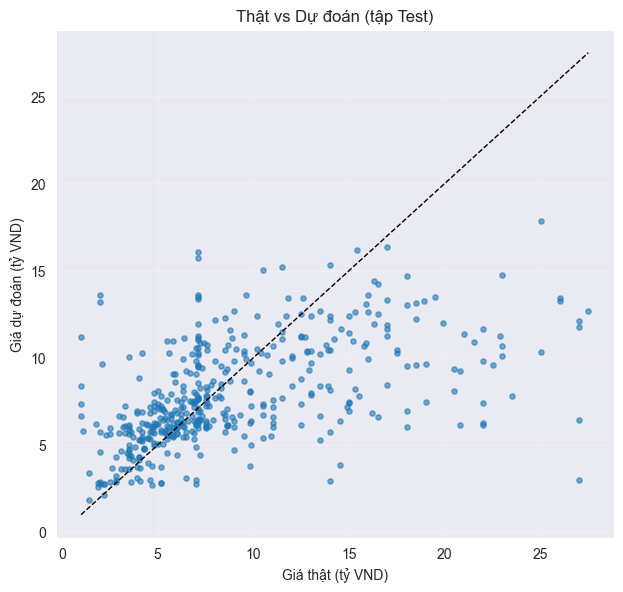

In [55]:
fig, ax = plt.subplots(figsize=(7.2, 6.6))
plot_parity(ax, y_test, y_pred_test, title="Thật vs Dự đoán (tập Test)")
plt.show()
fig.savefig(OUTDIR / "plot_parity.png", dpi=180)


## 13) Residual histogram

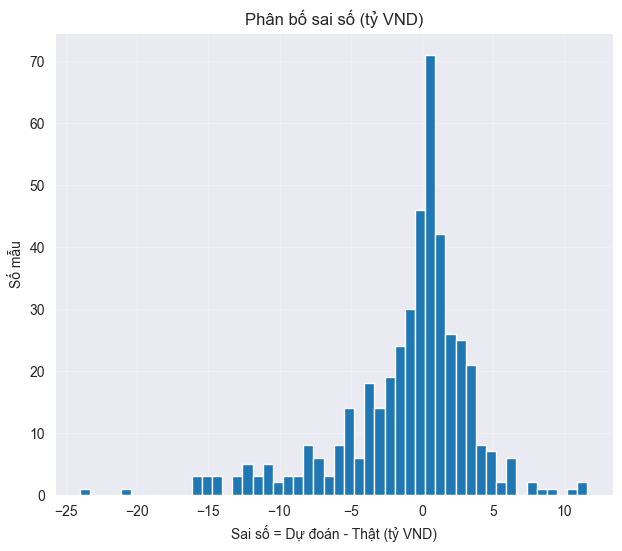

In [56]:
fig, ax = plt.subplots(figsize=(7.2, 6.0))
plot_residual_hist(ax, y_test, y_pred_test, bins=50)
plt.show()
fig.savefig(OUTDIR / "plot_residual_hist.png", dpi=180)


## 14) Residual vs Predicted

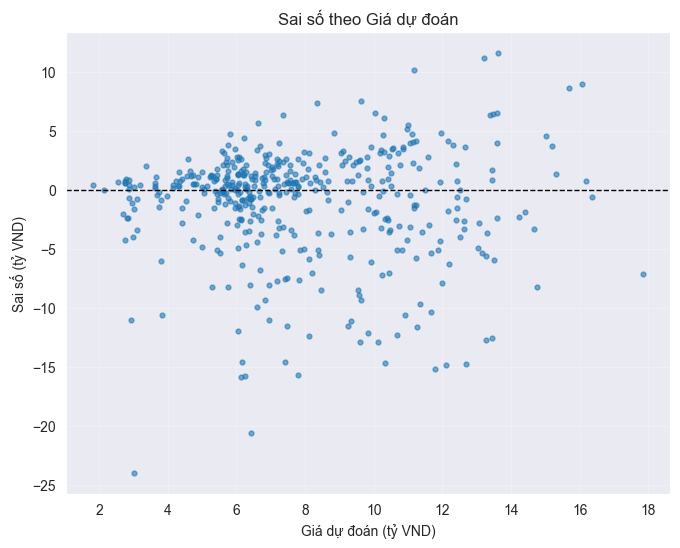

In [57]:
fig, ax = plt.subplots(figsize=(7.8, 6.0))
plot_residual_scatter(ax, y_pred_test, y_test)
plt.show()
fig.savefig(OUTDIR / "plot_residual_vs_pred.png", dpi=180)


## 15) Lỗi theo quận (MAE)

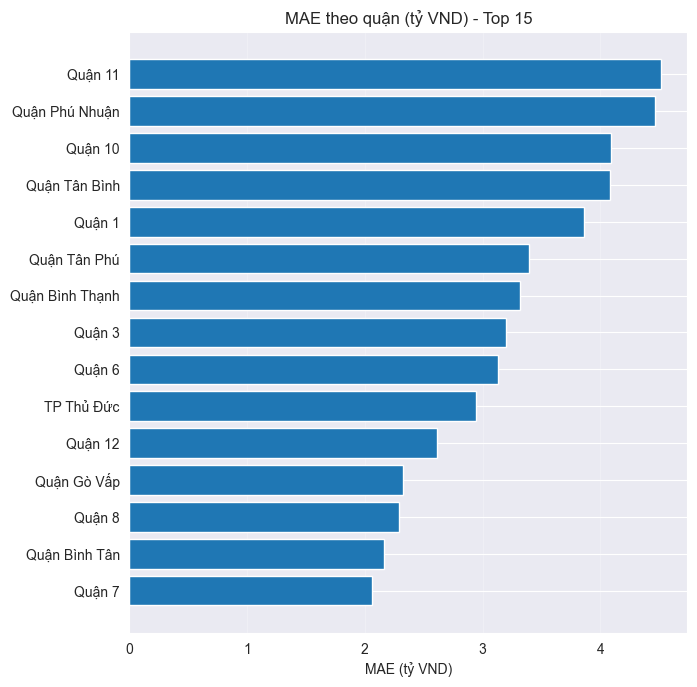

In [58]:
fig, ax = plt.subplots(figsize=(7.2, 7.8))
test_with_district = X_test.copy()
test_with_district["Quận/Huyện/TP"] = test_with_district["Quận/Huyện/TP"].astype(str)
plot_error_by_district(ax, test_with_district, y_test.values, y_pred_test, top=15, agg="mae")
plt.show()
fig.savefig(OUTDIR / "plot_error_by_district.png", dpi=180)


## 17) Learning Curve

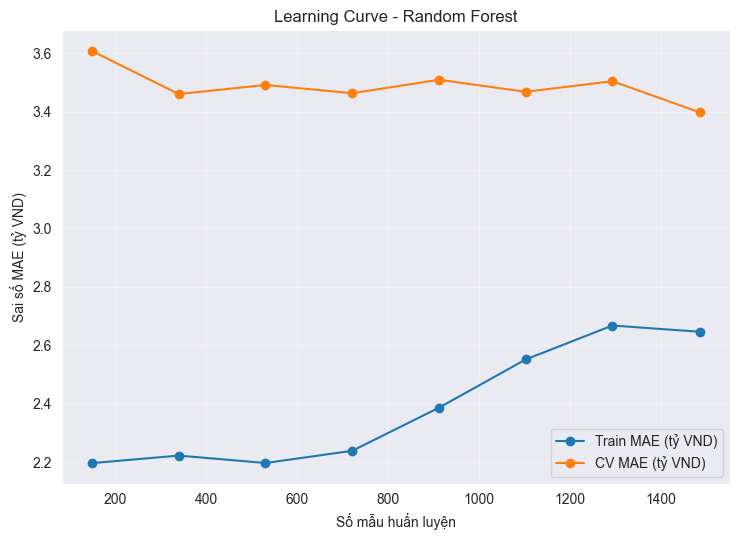

📊 Saved: model_out\rf_learning_curve.png


In [59]:
# === Hiệu năng 1: Learning Curve (độ chính xác theo số mẫu huấn luyện) ===
fig, ax = plt.subplots(figsize=(7.5, 5.5))
plot_learning_curve(
    model=model,      # pipeline đã huấn luyện
    X=X,              # toàn bộ dữ liệu đầu vào
    y=y,              # biến mục tiêu
    ax=ax,
    scoring="neg_mean_absolute_error",
    cv=3,
    random_state=RANDOM_STATE
)
plt.tight_layout()
plt.show()

# Lưu ảnh
out_lc = OUTDIR / "rf_learning_curve.png"
fig.savefig(out_lc, dpi=180)
print("📊 Saved:", out_lc)


## 18) Validation Curve

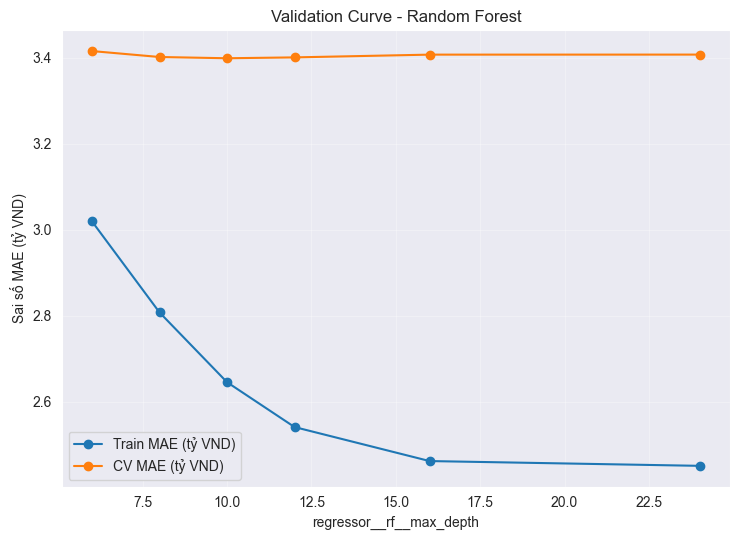

📈 Saved: model_out\rf_validation_curve_max_depth.png


In [60]:
# === Hiệu năng 2: Validation Curve (hiệu năng theo độ sâu cây RF) ===
fig, ax = plt.subplots(figsize=(7.5, 5.5))

param_name = "regressor__rf__max_depth" if LOG_TARGET else "rf__max_depth"

plot_validation_curve(
    model=model,
    X=X,
    y=y,
    ax=ax,
    param_name=param_name,
    param_range=[None, 6, 8, 10, 12, 16, 24],  # có thể thử None để so sánh
    scoring="neg_mean_absolute_error",
    cv=3
)
plt.tight_layout()
plt.show()

out_vc = OUTDIR / "rf_validation_curve_max_depth.png"
fig.savefig(out_vc, dpi=180)
print("📈 Saved:", out_vc)


## 19) Lưu model 

In [61]:

joblib.dump(model, model_path)
print("✅ Saved model pipeline:", model_path)
REQUIRED_COLUMNS = ["Diện tích sử dụng", "Diện tích đất", "Số ngày từ đăng", "Tỷ lệ sử dụng", "Quận/Huyện/TP"]
print("🔎 Required columns for prediction:", REQUIRED_COLUMNS)

✅ Saved model pipeline: model_out\rf_price_pipeline.joblib
🔎 Required columns for prediction: ['Diện tích sử dụng', 'Diện tích đất', 'Số ngày từ đăng', 'Tỷ lệ sử dụng', 'Quận/Huyện/TP']


## 20) Hàm dự đoán nhanh (trả về VND & tỷ VND)

In [62]:
def predict_price(area_use, area_land, age_days, district):
    """
    Dự đoán giá với model đã train.
    - area_use: Diện tích sử dụng (m²)
    - area_land: Diện tích đất (m²)
    - age_days: Số ngày từ đăng
    - district: tên quận/huyện (ví dụ 'Quận 1', 'Huyện Bình Chánh', 'TP Thủ Đức', ...)
    """
    # Tỷ lệ sử dụng (an toàn với chia 0)
    ratio = np.nan
    try:
        ratio = (float(area_use) / float(area_land)) if float(area_land) != 0 else np.nan
    except Exception:
        ratio = np.nan

    new_df = pd.DataFrame([{
        "Diện tích sử dụng": float(area_use),
        "Diện tích đất": float(area_land),
        "Số ngày từ đăng": float(age_days),
        "Tỷ lệ sử dụng": ratio,
        "Quận/Huyện/TP": str(district)
    }], columns=REQUIRED_COLUMNS)

    # Dự đoán (VND)
    pred_vnd = float(model.predict(new_df)[0])
    pred_bil = pred_vnd / 1e9
    return pred_vnd, pred_bil, new_df


## 21) Demo dự đoán

In [63]:
 # Dự đoán 5 ví dụ minh hoạ
examples = [
    # 1. Căn hộ trung tâm (cao cấp)
    dict(area_use=75, area_land=80, age_days=10, district="Quận 1"),

    # 2. Nhà mặt phố khu dân cư (giá cao vừa)
    dict(area_use=85, area_land=90, age_days=5, district="Quận 3"),

    # 3. Nhà tầm trung vùng ven (giá trung bình)
    dict(area_use=100, area_land=110, age_days=20, district="TP Thủ Đức"),

    # 4. Nhà ngoại thành (giá thấp)
    dict(area_use=90, area_land=100, age_days=60, district="Huyện Bình Chánh"),

    # 5. Đất hoặc nhà xa trung tâm (rẻ nhất)
    dict(area_use=120, area_land=130, age_days=40, district="Huyện Củ Chi"),
]

# Lưu kết quả
rows = []
for ex in examples:
    pv_vnd, pv_bil, _row = predict_price(**ex)
    _row["Giá dự đoán (VND)"] = pv_vnd
    _row["Giá dự đoán (Tỷ)"] = pv_bil
    rows.append(_row)

# Gộp và hiển thị
df_pred_demo = pd.concat(rows, ignore_index=True)
display(df_pred_demo[
    ["Quận/Huyện/TP", "Diện tích sử dụng", "Diện tích đất", 
     "Số ngày từ đăng", "Tỷ lệ sử dụng", "Giá dự đoán (Tỷ)", "Giá dự đoán (VND)"]
].style.format({"Giá dự đoán (VND)": "{:,.0f}", "Giá dự đoán (Tỷ)": "{:.3f}"}))

# In ra gọn gàng
for _, r in df_pred_demo.iterrows():
    print(f"🏠 {r['Quận/Huyện/TP']:<20} | "
          f"Diện tích: {r['Diện tích sử dụng']:>3.0f}/{r['Diện tích đất']:>3.0f} m² | "
          f"Giá dự đoán: {r['Giá dự đoán (Tỷ)']:.2f} tỷ ({r['Giá dự đoán (VND)']:,.0f} VND)")


,Quận/Huyện/TP,Diện tích sử dụng,Diện tích đất,Số ngày từ đăng,Tỷ lệ sử dụng,Giá dự đoán (Tỷ),Giá dự đoán (VND)
0,Quận 1,75.000000,80.000000,10.000000,0.937500,6.780,"6,780,410,093"
1,Quận 3,85.000000,90.000000,5.000000,0.944444,6.962,"6,962,000,423"
2,TP Thủ Đức,100.000000,110.000000,20.000000,0.909091,6.583,"6,582,819,997"
3,Huyện Bình Chánh,90.000000,100.000000,60.000000,0.900000,7.047,"7,047,339,034"
4,Huyện Củ Chi,120.000000,130.000000,40.000000,0.923077,10.168,"10,168,322,390"


🏠 Quận 1               | Diện tích:  75/ 80 m² | Giá dự đoán: 6.78 tỷ (6,780,410,093 VND)
🏠 Quận 3               | Diện tích:  85/ 90 m² | Giá dự đoán: 6.96 tỷ (6,962,000,423 VND)
🏠 TP Thủ Đức           | Diện tích: 100/110 m² | Giá dự đoán: 6.58 tỷ (6,582,819,997 VND)
🏠 Huyện Bình Chánh     | Diện tích:  90/100 m² | Giá dự đoán: 7.05 tỷ (7,047,339,034 VND)
🏠 Huyện Củ Chi         | Diện tích: 120/130 m² | Giá dự đoán: 10.17 tỷ (10,168,322,390 VND)
